<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/supplemental_materials/weapons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q geopandas networkx

In [3]:
!pip install "git+https://github.com/DS-20195/notebooks#egg=ds20195&subdirectory=lib"

  Cloning https://github.com/DS-20195/notebooks to /tmp/pip-install-6skp1iwx/ds20195_5c82c7e4c1f24dc68a28d3c522b2b6f6
  Running command git clone --filter=blob:none --quiet https://github.com/DS-20195/notebooks /tmp/pip-install-6skp1iwx/ds20195_5c82c7e4c1f24dc68a28d3c522b2b6f6
  Resolved https://github.com/DS-20195/notebooks to commit 550dcfb5255d76a520ecfbb240ef95958339176e
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.9 MB/s eta 0:00:00:00:01
  Created wheel for ds20195: filename=ds20195-0.0.1-py3-none-any.whl size=3688 sha256=02de18327ce73bb046672c3c91e6c39764cfed4f28f72bbd2a2ce1afcc050f35
  Stored in directory: /tmp/pip-ephem-wheel-cache-1a77wm17/wheels/24/47/8f/2780756f1cf00353089b7ee711e2b4c944ef371f5c37082c7d
Successfully built ds20195
  Attempting uninstall: gspread
    Found existing installation: gspread 6.2.1
    Uninstalling gspread-6.2.1:
  

In [4]:
%config InlineBackend.figure_formats = ["svg"]
import base64
import io
import json
import requests

import pandas as pd; pd.set_option('display.max_rows', 500)
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from shapely import Point
from ds20195 import google_sheets_credentials, generate_flow_sheet

# Week 5: Graphs, flows, and arms

### Fetching SIPRI flow data

This is a case study in real-world data munging.  There is extensive pre-processing to do to make the data useable.  We've chosen to show it to you in this notebook so that you get a realistic sense of the data challenges of working with a new dataset by reading through the notebook.  (Of course, you can also just click through it and everything should work.)

We're going to be working with a dataset from SIPRI (the Stockholm International Peace Research Institute) that tracks how arms and weaponry move around the world.

They have created a unit of weaponry called TIV ("trend indicator value"), which is an attempt to measure comparable amounts of **military capability**. It's some mix of cost and lethality that is designed to make it possible to compare arms flows across type and time.

For more on TIV, see the SIPRI fact sheet ["Measuring International Arms Transfers"](https://www.sipri.org/sites/default/files/files/FS/SIPRIFS1212.pdf).

SIPRI doesn't intend for users to grab their full dataset all at once, but we've figured out how to pull the whole CSV without any filters.  This might take a minute or more to run.  If it times out, try it again!

In [5]:
raw_data = requests.post(
    "https://atbackend.sipri.org/api/p/trades/trade-register-csv/",
    json={"filters": []},
).json()

Next, it turns out to be encoded in base 64, and we have to convert it to a more standard format.  Base 64 is a pretty nonstandard format, often used because it can encompass special characters, so it's important to notice the need to translate it or subsequent manipulations won't work as expected.

When you run the next cell, we'll examine the first 15 lines of the decoded file, which turns out to be a text header that needs to be chopped off the CSV for the rest of our work.  So we split at the carriage return (`split("\n")`) before continuing.

In [6]:
csv_lines = base64.b64decode(raw_data["bytes"]).decode("iso-8859-1").split("\n")
csv_lines[:15]

["Transfers of major conventional arms from All countries  to All countries . Deals with deliveries made for the year range 'Not specified' to 'Not specified' ",
 "A '?' in a column indicates uncertain data. The 'Number delivered' and the 'Year(s) of deliveries' refer only to deliveries in the selected year(s).",
 "An empty field for 'Number ordered' indicates that data is not yet available.",
 'SIPRI trend-indicator values (TIVs) are in millions.',
 "An empty field for 'SIPRI TIV for total order' indicates that data (on the number ordered and/or the TIV per unit) is not available.",
 "A '0' for 'SIPRI TIV of delivered weapons' indicates that the volume of deliveries is between 0 and 0.5 million SIPRI TIV; and an empty field indicates that no deliveries have been identified.",
 'Figures may not add up to stated totals due to the conventions of rounding.',
 'For the method used for the SIPRI TIV and explanations of the conventions; abbreviations and acronyms see <https://www.sipri.org/d

In [7]:
first_line_index = next(idx for idx, line in enumerate(csv_lines) if line.startswith("Recipient,"))
first_line_index

11

Let's make the dataframe!  It's got a huge amount of information about the weapons, when ordered, whether new or second-hand, and comments about the conflict context.

In [8]:
arms_df = pd.read_csv(io.StringIO("\n".join(csv_lines[first_line_index:])))
arms_df.to_csv("fulldata.csv")
arms_df

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00
29912,Zimbabwe,China,1990,?,2.0,NaN,J-7,fighter aircraft,2,NaN,1991,New,FT-7BZ version,9.00,18.00,18.00
29913,Zimbabwe,Italy,1967,?,20.0,?,Model-56 105mm,towed gun,20,?,1967,New,Supplier uncertain,0.45,9.00,9.00
29914,Zimbabwe,France,1977,?,3.0,NaN,Cessna-337/O-2,light aircraft,3,NaN,1977,New,NaN,0.35,1.05,1.05


In [9]:
arms_df.groupby(["Recipient", "Supplier", "Year of order"]).count()

Number ordered   .1  \
Recipient            Supplier           Year of order                           
ANC (South Africa)*  Soviet Union       1988           0               1    1   
Afghanistan          Belarus            2018           0               1    0   
                     Bosnia-Herzegovina 2009           0               1    0   
                                        2012           1               1    1   
                     Brazil             2013           0               1    0   
...                                                   ..             ...  ...   
unknown recipient(s) United States      1990           1               1    1   
                                        1995           0               1    0   
                                        2010           0               1    1   
                                        2018           2               2    2   
                                        2025           0               0    0   

                                                       Weapon designation  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Weapon description  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Number delivered   .2  \
Recipient            Supplier           Year of order                          
ANC (South Africa)*  Soviet Union       1988                          1    1   
Afghanistan          Belarus            2018                          1    0   
                     Bosnia-Herzegovina 2009                          1    1   
                                        2012                          1    0   
                     Brazil             2013                          1    1   
...                                                                 ...  ...   
unknown recipient(s) United States      1990                          1    1   
                                        1995                          1    0   
                                        2010                          1    1   
                                        2018                          2    2   
                                        

We can narrow down what we're looking at.  The next cell lets you toggle between looking for (a) [Mi-17s](https://en.wikipedia.org/wiki/Mil_Mi-17) that do not come from Russia/USSR, or (b) second-hand weapons.  Try it both ways.

In [10]:
# arms_df[(arms_df["Weapon designation"] == "Mi-17") & (arms_df["Supplier"] != "Russia") & (arms_df["Supplier"] != "Soviet Union")]
arms_df[arms_df["status"] == "Second hand"]

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29906,Zimbabwe,South Africa,1972,?,1.0,NaN,AL-60,light transport aircraft,1,NaN,1973,Second hand,Second-hand,0.10,0.10,0.10
29909,Zimbabwe,Spain,1988,?,1.0,?,C-212,transport aircraft,1,NaN,1990,Second hand,Second-hand; C-212-200 version,1.52,1.52,1.52
29910,Zimbabwe,South Africa,1976,?,1.0,NaN,BN-2 Islander,light transport aircraft,1,NaN,1977,Second hand,Second-hand,0.24,0.24,0.24
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00


What other statuses are possible?

In [11]:
arms_df["status"].unique()

array(['Second hand', 'New', 'Second hand but modernized'], dtype=object)

In [12]:
arms_df["Weapon designation"].value_counts()

,count
Weapon designation,
aircraft engine,439
ship engine,397
vehicle engine,283
Mi-17,241
M-113,227
...,...
KS-30 130mm,1
RGS-9316,1
Wusung,1


# Mapping transfers


Visualizing the SIPRI dataset presents several problems:

* Recipients and suppliers are _usually_ countries, but this does not always hold. Notice that the dataset includes non-state actors (such as the [Houthi rebels](https://en.wikipedia.org/wiki/Houthis) or the [Mujahideen](https://en.wikipedia.org/wiki/Afghan_mujahideen)).  We will need one lat/long location per actor, so we'll try to find an appropriate capital city.
* This dataset goes back to the 1940s, so it references countries that no longer exist (such as [Biafra](https://en.wikipedia.org/wiki/Biafra) and [Yugoslavia](https://en.wikipedia.org/wiki/Yugoslavia)).
* There is some variability in names. For instance, "Ivory Coast" and "Cote d'Ivoire" are two different names for the same country.

For visualization purposes, we'll map these special cases to the nearest equivalent contemporary states. For instance, we'll map South Vietnam to Vietnam; Saigon (the former capital of South Vietnam) is now Ho Chi Minh City (the current capital of Vietnam). We'll exclude flows to or from entities that do not clearly correspond to a single region (for instance, the United Nations).

The following dictionary associating SIPRI states to modern states was made by hand and represents a lot of labor!  You should at least glance through it to get a sense of some of the nitty-gritty involved here.  Note the comments at the end about non-obvious decisions (a good practice when cleaning data, so you'll know what you were thinking later on!) and the explicit list of exceptions.

In [13]:
capitals_map = {
    "ANC (South Africa)*": "South Africa",
    "Anti-Castro rebels (Cuba)*": "Cuba",
    "Amal (Lebanon)*": "Lebanon",
    "Armas (Guatemala)*": "Guatemala",
    "Contras (Nicaragua)*": "Nicaragua",
    "Darfur rebels (Sudan)*": "Sudan",
    "ELF (Ethiopia)*": "Ethiopia",
    "EPLF (Ethiopia)*": "Ethiopia",
    "FRELIMO (Portugal)*": "Portugal",
    "Haiti rebels*": "Haiti",
    "Hezbollah (Lebanon)*": "Lebanon",
    "Houthi rebels (Yemen)*": "Yemen",
    "Indonesia rebels*": "Indonesia",
    "Khmer Rouge (Cambodia)*": "Cambodia",
    "Kurdistan Regional Government (Iraq)*": "Iraq",
    "LF (Lebanon)*": "Lebanon",
    "LRA (Uganda)*": "Uganda",
    "LTTE (Sri Lanka)*": "Sri Lanka",
    "Libya GNC": "Libya",
    "Libya HoR*": "Libya",
    "HoR (Libya)*": "Libya",
    "Congo": "Congo (Brazzaville)",
    "DR Congo": "Congo (Kinshasa)",
    "MNLF (Philippines)*": "Philippines",
    "MPLA (Portugal)*": "Portugal",
    "MTA (Myanmar)*": "Myanmar",
    "Micronesia": "Federated States of Micronesia",
    "Mujahedin (Afghanistan)*": "Afghanistan",
    "NLA (Macedonia)*": "North Macedonia",
    "NTC (Libya)*": "Libya",
    "Northern Alliance (Afghanistan)*": "Afghanistan",
    "Northern Cyprus": "Cyprus",
    "PAIGC (Portugal)*": "Portugal",
    "PIJ (Israel/Palestine)*": "Israel",
    "PKK (Turkiye)*": "Turkey",
    "PLO (Israel)*": "Israel",
    "PRC (Israel/Palestine)*": "Israel",
    "Pathet Lao (Laos)*": "Laos",
    "Provisional IRA (UK)*": "United Kingdom",
    "RPF (Rwanda)*": "Rwanda",
    "RUF (Sierra Leone)*": "United Kingdom",
    "SLA (Lebanon)*": "Lebanon",
    "SNA (Somalia)*": "Somalia",
    "SPLA (Sudan)*": "Sudan",
    "Southern rebels (Yemen)*": "Yemen",
    "Syria rebels*": "Syria",
    "Turkiye": "Turkey",
    "UAE": "United Arab Emirates",
    "UIC (Somalia)*": "Somalia",
    "UNITA (Angola)*": "Angola",
    "Ukraine Rebels*": "Ukraine",
    "United States": "United States of America",
    "United Wa State (Myanmar)*": "Myanmar",
    "Viet Minh (France)*": "France",
    "Viet Nam": "Vietnam",
    "ZAPU (Zimbabwe)*": "Zimbabwe",
    "GUNT (Chad)*": "Chad",
    "FAN (Chad)*": "Chad",
    "FMLN (El Salvador)*": "El Salvador",
    "Gambia": "The Gambia",
    "Lebanon Palestinian rebels*": "Lebanon",
    "Cote d'Ivoire": "Ivory Coast",
    "Bahamas": "The Bahamas",
    "FNLA (Angola)*": "Angola",
    "Cabo Verde": "Cape Verde",
    "Timor-Leste": "East Timor",
    "Saint Vincent": "Saint Vincent and the Grenadines",
    "Guinea-Bissau": "Guinea Bissau",
    "South Vietnam": "Vietnam",  # Saigon is now Ho Chi Minh City
    "Viet Cong (South Vietnam)*": "Vietnam",
    "Hamas (Palestine)*": "Palestine",
    "Soviet Union": "Russia",
    "NATO**": "Belgium",  # NATO headquarters in Brussels
    'European Union**': "Belgium",  # EU headquarters in Brussels
    "OSCE**": "Austria",  # secretariat in Vienna
    "Yemen Arab Republic (North Yemen)": "Yemen",  # same capital as Yemen (Sanaa)
    "North Yemen": "Yemen",  # same capital as Yemen (Sanaa)
    "Czechoslovakia": "Czechia",  # same capital as the modern Czech Republic (Prague)
    "Yugoslavia": "Serbia",  # same capital as Serbia (Belgrade)
    "East Germany (GDR)": "Germany",  # for large-scale flow maps, approximate East Berlin with Berlin
    "Western Sahara": "Morocco",  # largely under Moroccan occupation
}

exclude_flows = {
    "nan",
    "unknown rebel group*",
    "unknown recipient(s)",
    'unknown supplier(s)',
    "United Nations**",
    "Regional Security System**",
    "African Union**",
    '0.25',
    '3',
}


Even more exceptions!  These lat/longs were added by hand.

In [14]:
# (long, lat) coordinates for capitals of entities not included in the places shapefile.
# Several of these entities are countries that no longer exist.
extra_capitals = {
    "Biafra": ("Enugu", 7.5139, 6.4483),  # 1967 capital (now part of Nigeria)
    "Bosnia-Herzegovina": ("Sarajevo", 18.4131, 43.8563),
    "South Yemen": ("Aden", 45.0176, 12.7906),
    "Katanga": ("Lubumbashi", 27.5026, -11.6876),
    "South Sudan": ("Juba",  31.5825, 4.8539),
    "Palestine": ("East Jerusalem", 35.217018, 31.771959),
    "Aruba": ("Oranjestad", -70.0353, 12.5227),
}

...and put into a format that's suitable for adding to the capitals list we're making.  Note the CRS (coordinate reference system) specified.

In [15]:
extra_capitals_gdf = gpd.GeoDataFrame(
    [
        {
            "adm0name": entity,
            "name": capital,
            "longitude": long,
            "latitude": lat,
            "geometry": Point(long, lat),
        }
        for entity, (capital, long, lat) in extra_capitals.items()
    ],
    crs="epsg:4326",
).set_index("adm0name")
extra_capitals_gdf

,name,longitude,latitude,geometry
adm0name,,,,
Biafra,Enugu,7.513900,6.448300,POINT (7.5139 6.4483)
Bosnia-Herzegovina,Sarajevo,18.413100,43.856300,POINT (18.4131 43.8563)
South Yemen,Aden,45.017600,12.790600,POINT (45.0176 12.7906)
Katanga,Lubumbashi,27.502600,-11.687600,POINT (27.5026 -11.6876)
South Sudan,Juba,31.582500,4.853900,POINT (31.5825 4.8539)
Palestine,East Jerusalem,35.217018,31.771959,POINT (35.21702 31.77196)
Aruba,Oranjestad,-70.035300,12.522700,POINT (-70.0353 12.5227)


Next we're going to read in a simple shapefile from a cartographic society that gives locations for major world cities and identifies which ones are capital cities.  Note even more special-case handling:  some countries have more than one capital!  (South Africa famously has three.)

In [16]:
places_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip")
capitals_gdf = places_gdf[places_gdf["adm0cap"] == 1].set_index("adm0name")
# force each nation to have exactly one capital
capitals_gdf = capitals_gdf[~capitals_gdf["name"].isin(["Sucre", "Yamoussoukro", "Bloemfontein", "Pretoria"])][["name", "latitude", "longitude", "geometry"]]
capitals_gdf = gpd.GeoDataFrame(pd.concat([capitals_gdf, extra_capitals_gdf]), crs="epsg:4326")

In [17]:
capitals_gdf.tail(100)

,name,latitude,longitude,geometry
adm0name,,,,
Albania,Tirana,41.327541,19.818883,POINT (19.81888 41.32754)
Armenia,Yerevan,40.183097,44.511606,POINT (44.51161 40.1831)
Azerbaijan,Baku,40.397218,49.860271,POINT (49.86027 40.39722)
Cambodia,Phnom Penh,11.551976,104.914689,POINT (104.91469 11.55198)
Bolivia,La Paz,-16.496028,-68.151931,POINT (-68.15193 -16.49603)
Benin,Cotonou,6.401954,2.518045,POINT (2.40435 6.36298)
Bulgaria,Sofia,42.685295,23.314708,POINT (23.31471 42.6853)
Belarus,Minsk,53.901923,27.564681,POINT (27.56468 53.90192)
Bhutan,Thimphu,27.472986,89.639014,POINT (89.63901 27.47299)


Hopefully this dataset gives you many ideas of things you could analyze.

Here are just a few...
* Study arms flows connected to a protracted conflict (e.g., Israel–Palestine)
* Pick a small window of time, like 1-2 years, and do a deeper look at that snapshot.
* The USSR collapsed circa 1991.  Do you see an immediate impact on arms flows?
* Consider second-hand arms sales.  How does weaponry "trickle down" from rich exporters to first and then second recipients.
* How does the popularity and regionality of a particular weapon (e.g., the Mi-17) change over time?

## Exploration

In [21]:
arms_df.columns

Index(['Recipient', 'Supplier', 'Year of order', ' ', 'Number ordered', ' .1',
       'Weapon designation', 'Weapon description', 'Number delivered', ' .2',
       'Year(s) of delivery', 'status', 'Comments', 'SIPRI TIV per unit',
       'SIPRI TIV for total order', 'SIPRI TIV of delivered weapons'],
      dtype='object')

In [41]:
# Save current max_colwidth option
_prev_colwidth = pd.get_option('display.max_colwidth')
# Set max_colwidth to None to display full text
pd.set_option('display.max_colwidth', None)

# Display the Comments column with full text
display(arms_df[arms_df.Comments.str.contains("for ", na=False)]\
    .sample(40, random_state=13)[['Supplier', 'Recipient', 'Year of order', 'Comments']])

# Restore the previous max_colwidth option
pd.set_option('display.max_colwidth', _prev_colwidth)

,Supplier,Recipient,Year of order,Comments
27914,France,United Arab Emirates,1998,Black Shaheen version (with reduced range to conform to 300km MTCR limits); for Mirage-2000-9 combat aircraft
18587,United States,Oman,2002,Part of $1.1 b deal; for F-16C combat aircraft
28760,Sweden,Uruguay,1990,Scania DS-14 diesel engine for modernization of 22 M-41 tanks; from production line in Brazil
8170,Italy,Finland,1984,AB-412EP version; for border guard
6089,United States,Denmark,1994,RIM-7M Sea Sparrow surface-to-air version; for Flyvefisken missile boats/minehunters and modernized Niels Juel corvetets; incl production of components in Denmark as part of 'NSSMS' progamme
22292,Israel,Singapore,1986,For 6 MGB-62 (Victory) corvettes from FRG; for use with Barak SAM
10819,France,India,1966,Probably for Hunter combat aircraft
13567,United States,Japan,1988,Produced under licence in Japan as KV-107-II-5; for SAR
4988,Germany,Colombia,2009,MTU 16V-1163 (7000hp) diesel engine for modernization of 4 FS-1500 (Padilla) frigates
23016,Germany,South Korea,1984,D2848T (350hp) diesel engine for some 150 K-263 self-propelled anti-aircraft guns produced in South Korea; produced under licence in South Korea


In [ ]:
# Show the number of rows in original arms_df where "deal" appears in the "Comments" column (case-insensitive)
word = " aid"
num_deal_rows = arms_df['Comments'].str.contains(word, case=False, na=False).sum()
print(f'Number of rows with "{word}" in Comments column: {num_deal_rows}')

Number of rows with "aid" in Comments column: 3166


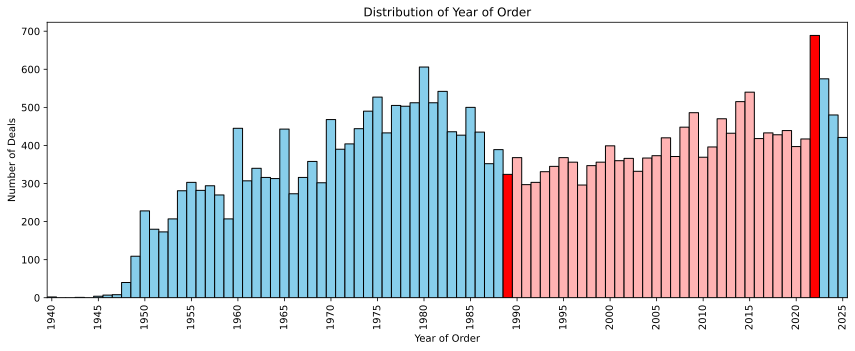

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Drop missing or NaN years, convert to int if needed
years = arms_df["Year of order"].dropna().astype(int)

# Get unique years for full range, for ticks and highlighting
min_year, max_year = years.min(), years.max()

# Define bins so each year is a bin of size 1
bins = np.arange(min_year, max_year + 2, 1)  # right edge exclusive

fig, ax = plt.subplots(figsize=(12, 5))
n, bins_, patches = ax.hist(years, bins=bins, color='skyblue', edgecolor='black', align='mid')

# Highlight:
# - Years 1990-2024 (between 1989 and 2025) in light red
# - Years 1989 and 2025 in dark red
for patch, left_edge, right_edge in zip(patches, bins_[:-1], bins_[1:]):
    bin_year = int(left_edge)
    if 1990 <= bin_year <= 2021s:
        patch.set_facecolor('#ffb3b3')  # light red
    elif bin_year == 1989 or bin_year == 2022:
        patch.set_facecolor('red')       # dark red

# Set title and labels
ax.set_title("Distribution of Year of Order")
ax.set_xlabel("Year of Order")
ax.set_ylabel("Number of Deals")

# Only show ticks for years divisible by five (ending in 0 or 5)
tick_years = [year for year in bins_[:-1] if int(year) % 5 == 0 or int(year) % 5 == 5]
tick_centers = [y + 0.5 for y in tick_years]
ax.set_xticks(tick_centers)
ax.set_xticklabels([str(int(y)) for y in tick_years], rotation=90)
ax.set_xlim(bins_[0], bins_[-1])

plt.tight_layout()
plt.show()

# Building a graph

To make a visual that shows the movement, a natural data object is a **graph**, in the sense of discrete mathematics.  A graph is made up of vertices (also called nodes), with some of them connected by edges.  The edges can be weighted, and can have a direction.  So a flow can be represented as a weighted directed edge from vertex $v$ to vertex $w$.

We'll set this up with a dataframe giving only a limited number of attributes per state, then a secondary dataframe grouping by year.

In [17]:
flowmap_arms_df = arms_df[~arms_df["Supplier"].isin(exclude_flows) & ~arms_df["Recipient"].isin(exclude_flows)].rename(
    columns={
        "Year of order": "order_year",
        "Recipient": "recipient",
        "Supplier": "supplier",
        "SIPRI TIV for total order": "order_sipri_tiv"
    }
)
flowmap_arms_df["order_year"] = flowmap_arms_df["order_year"].astype(int)
flowmap_arms_df = flowmap_arms_df[flowmap_arms_df["order_year"] >= 1950]

In [18]:
orders_by_year_df = flowmap_arms_df.groupby(["order_year", "recipient", "supplier"]).sum()["order_sipri_tiv"]
orders_by_year_df

order_year  recipient      supplier      
1950        Argentina      United States     135.51
            Australia      United Kingdom    337.68
                           United States       0.60
            Belgium        United Kingdom     78.00
                           United States     763.02
                                              ...  
2025        United States  Sweden              0.00
            Uruguay        Brazil              0.56
                           Italy               2.00
            Uzbekistan     Turkiye             0.00
            Viet Nam       South Korea       150.00
Name: order_sipri_tiv, Length: 15656, dtype: float64

## Example
Let's visualize arms flows to and from the U.S. in a particular year by constructing a graph.

In [19]:
year = 1980
country = "United States"

In [20]:
filtered_orders_df = orders_by_year_df[year].reset_index()
filtered_orders_df = filtered_orders_df[
    (filtered_orders_df["recipient"] == "United States")
    | (filtered_orders_df["supplier"] == "United States")
]
filtered_orders_df.head(10)

,recipient,supplier,order_sipri_tiv
13,Argentina,United States,46.50
17,Australia,United States,481.60
18,Austria,United States,105.00
21,Bangladesh,United States,14.80
25,Bolivia,United States,5.64
31,Brunei,United States,1.40
36,Canada,United States,4335.26
45,Chile,United States,45.20
50,Colombia,United States,42.92
53,Costa Rica,United States,0.44


We imported NetworkX above as `nx`.  Our graph will have directed edges FROM the supplier TO the recipient of an arms shipment.

In [21]:
orders_graph = nx.DiGraph()

for _, row in filtered_orders_df.iterrows():
    orders_graph.add_edge(
        row.supplier,
        row.recipient,
        weight=row.order_sipri_tiv,
    )

Where did the U.S. send arms that year?  (or receive from!)

In [22]:
orders_graph.edges

OutEdgeView([('United States', 'Argentina'), ('United States', 'Australia'), ('United States', 'Austria'), ('United States', 'Bangladesh'), ('United States', 'Bolivia'), ('United States', 'Brunei'), ('United States', 'Canada'), ('United States', 'Chile'), ('United States', 'Colombia'), ('United States', 'Costa Rica'), ('United States', 'Denmark'), ('United States', 'Dominican Republic'), ('United States', 'Ecuador'), ('United States', 'Egypt'), ('United States', 'El Salvador'), ('United States', 'Finland'), ('United States', 'Gabon'), ('United States', 'Germany'), ('United States', 'Greece'), ('United States', 'Guatemala'), ('United States', 'Honduras'), ('United States', 'Indonesia'), ('United States', 'Israel'), ('United States', 'Italy'), ('United States', 'Jamaica'), ('United States', 'Japan'), ('United States', 'Jordan'), ('United States', 'Kenya'), ('United States', 'Malaysia'), ('United States', 'Mauritania'), ('United States', 'Morocco'), ('United States', 'Myanmar'), ('United 

Next we'll make a static map.  You can play around with thickness and color of the directed edges.

In [23]:
def cast_point(p):
    return (p.xy[0][0], p.xy[1][0])

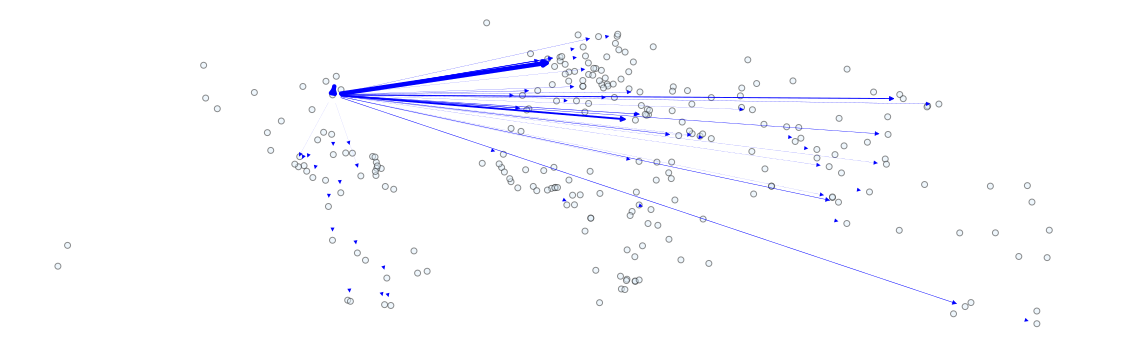

In [24]:
fig, ax = plt.subplots(figsize=(20, 40))
ax.axis("off")
places_gdf.plot(ax=ax, edgecolor="0.1", linewidth=1, color="#e1f1fd", alpha=0.5)

pos = dict(capitals_gdf.geometry)

for edge in orders_graph.edges(data='weight'):
    if edge[0] in exclude_flows or edge[1] in exclude_flows:
        continue

    edge_pos = {
        edge[0]: cast_point(pos[capitals_map.get(edge[0], edge[0])]),
        edge[1]: cast_point(pos[capitals_map.get(edge[1], edge[1])]),
    }
    nx.draw_networkx_edges(orders_graph, edge_pos, edgelist=[edge], width=0.001 * edge[2], ax=ax, edge_color="blue")

## FlowmapBlue

This line will pop up a dialog asking for permission to generate Google Sheets credentials using your Google login.  If you're doing this in Colab, it should be particularly seamless.

In [ ]:
flowmap_locations_df = pd.DataFrame(
    [
        {
            "id": loc,
            "name": loc,
            "lat": capitals_gdf.loc[capitals_map.get(loc, loc), "latitude"],
            "lon": capitals_gdf.loc[capitals_map.get(loc, loc), "longitude"],
        }
        for loc in set(flowmap_arms_df["supplier"]) | set(flowmap_arms_df["recipient"])
    ]
)
flowmap_locations_df.head(5)

,id,name,lat,lon
0,Cyprus,Cyprus,35.166677,33.366635
1,Bulgaria,Bulgaria,42.685295,23.314708
2,Guinea-Bissau,Guinea-Bissau,11.865024,-15.598361
3,MTA (Myanmar)*,MTA (Myanmar)*,19.768503,96.116673
4,United States,United States,38.901495,-77.011364


If you don't want to go through the whole Google permissions thing, read this [Medium article](https://medium.com/@a.marenkov/how-to-get-credentials-for-google-sheets-456b7e88c430) for info about getting credentials.

In [ ]:
sheet_creds = google_sheets_credentials()

MessageError: Error: credential propagation was unsuccessful

In [ ]:
flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=flowmap_locations_df,
    created_by_name="",  # YOUR NAME HERE
    created_by_email="", # YOUR EMAIL HERE
    data_source_name="SIPRI Arms Transfers Database",
    data_source_url="https://www.sipri.org/databases/armstransfers",
    incoming_tooltip="Inbound arms transfers (TIV)",
    outgoing_tooltip="Outbound arms transfers (TIV)",
    flow_tooltip="Arms transfer (TIV)",
    total_unit="TIVs",
    sheet_title="PUBPOL 2130: SIPRI arms transfers (orders over time)",
    flow_title="SIPRI Arms Transfers Database: orders over time",
    flows={
        f"Year: {year}": year_df.reset_index().rename(columns={
            "supplier": "origin",
            "recipient": "dest",
            "order_sipri_tiv": "count",
        })
        for year, year_df in orders_by_year_df.groupby(level=0)
    }
)

In [ ]:
print(flow_sheet.url)

In [ ]:
print(f"https://www.flowmap.blue/{flow_sheet.url.split('/')[-1]}")